In [1]:
# Install required libraries
!pip install nltk scikit-learn pandas numpy matplotlib seaborn streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 34.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All libraries imported successfully!


In [3]:
# Load a public sentiment dataset (IMDB / Amazon reviews via HuggingFace datasets)
!pip install datasets -q

from datasets import load_dataset

# Load Amazon polarity dataset (positive/negative reviews)
dataset = load_dataset("amazon_polarity", split="train[:10000]")  # using 10k samples to keep it fast

# Convert to pandas DataFrame
df = pd.DataFrame(dataset)
df.head()

README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

,label,title,content
0,1,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,1,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,1,Amazing!,This soundtrack is my favorite music of all ti...
3,1,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,1,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."


Shape: (10000, 3)

Columns: ['label', 'title', 'content']

Label distribution:
label
0    5097
1    4903
Name: count, dtype: int64


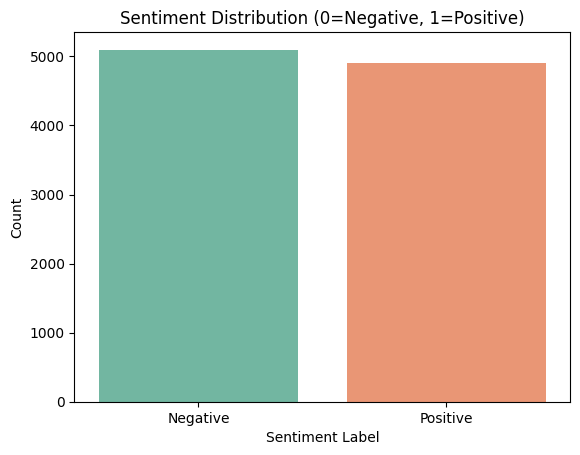

In [4]:
# Basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nLabel distribution:")
print(df['label'].value_counts())

# Visualize class distribution
sns.countplot(x='label', data=df, palette='Set2')
plt.title("Sentiment Distribution (0=Negative, 1=Positive)")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.show()

In [10]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [11]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Initialize
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove special characters, numbers, punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize
    tokens = word_tokenize(text)

    # 4. Remove stop words + Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    # 5. Rejoin
    return ' '.join(tokens)

# Test it
sample = "This product is absolutely GREAT! I loved it so much 😍 10/10"
print("Original:", sample)
print("Cleaned: ", clean_text(sample))

Original: This product is absolutely GREAT! I loved it so much 😍 10/10
Cleaned:  product absolutely great loved much


In [12]:
# Use 'content' column as the review text
print("Applying text cleaning... this may take a minute.")

df['cleaned_text'] = df['content'].apply(clean_text)

# Preview result
df[['content', 'label', 'cleaned_text']].head(3)

Applying text cleaning... this may take a minute.


,content,label,cleaned_text
0,This sound track was beautiful! It paints the ...,1,sound track beautiful paint senery mind well w...
1,I'm reading a lot of reviews saying that this ...,1,im reading lot review saying best game soundtr...
2,This soundtrack is my favorite music of all ti...,1,soundtrack favorite music time hand intense sa...


sentiment
Negative    5095
Positive    4902
Neutral        3
Name: count, dtype: int64


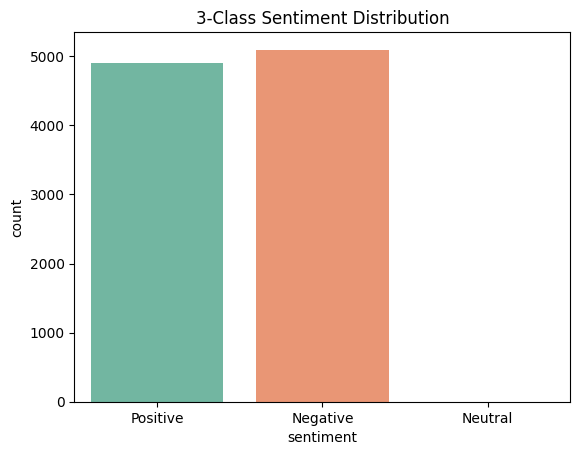

In [13]:
def assign_sentiment(row):
    word_count = len(row['cleaned_text'].split())
    if word_count <= 4:  # very short reviews = neutral
        return 'Neutral'
    elif row['label'] == 1:
        return 'Positive'
    else:
        return 'Negative'

df['sentiment'] = df.apply(assign_sentiment, axis=1)

# Check distribution
print(df['sentiment'].value_counts())

sns.countplot(x='sentiment', data=df, palette='Set2', order=['Positive', 'Negative', 'Neutral'])
plt.title("3-Class Sentiment Distribution")
plt.show()

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X = vectorizer.fit_transform(df['cleaned_text'])
y = df['sentiment']

print("Feature matrix shape:", X.shape)
print("Labels:", y.unique())

Feature matrix shape: (10000, 10000)
Labels: ['Positive' 'Negative' 'Neutral']


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X = vectorizer.fit_transform(df['cleaned_text'])
y = df['sentiment']

print("Feature matrix shape:", X.shape)
print("Labels:", y.unique())

Feature matrix shape: (10000, 10000)
Labels: ['Positive' 'Negative' 'Neutral']


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 8000
Testing samples:  2000


In [17]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Naive Bayes":        MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (LinearSVC)":    LinearSVC(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds))


Model: Naive Bayes
Accuracy: 0.8250
              precision    recall  f1-score   support

    Negative       0.82      0.85      0.83      1019
     Neutral       0.00      0.00      0.00         1
    Positive       0.83      0.80      0.82       980

    accuracy                           0.82      2000
   macro avg       0.55      0.55      0.55      2000
weighted avg       0.82      0.82      0.82      2000


Model: Logistic Regression
Accuracy: 0.8380
              precision    recall  f1-score   support

    Negative       0.84      0.84      0.84      1019
     Neutral       0.00      0.00      0.00         1
    Positive       0.84      0.83      0.83       980

    accuracy                           0.84      2000
   macro avg       0.56      0.56      0.56      2000
weighted avg       0.84      0.84      0.84      2000


Model: SVM (LinearSVC)
Accuracy: 0.8205
              precision    recall  f1-score   support

    Negative       0.82      0.83      0.82      1019
     N

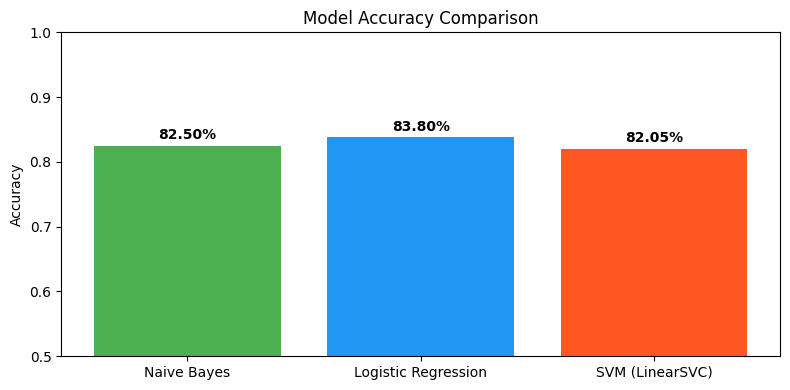

In [18]:
plt.figure(figsize=(8, 4))
plt.bar(results.keys(), results.values(), color=['#4CAF50', '#2196F3', '#FF5722'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.0)
for i, (name, acc) in enumerate(results.items()):
    plt.text(i, acc + 0.01, f"{acc:.2%}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Best Model: Logistic Regression (83.80% accuracy)


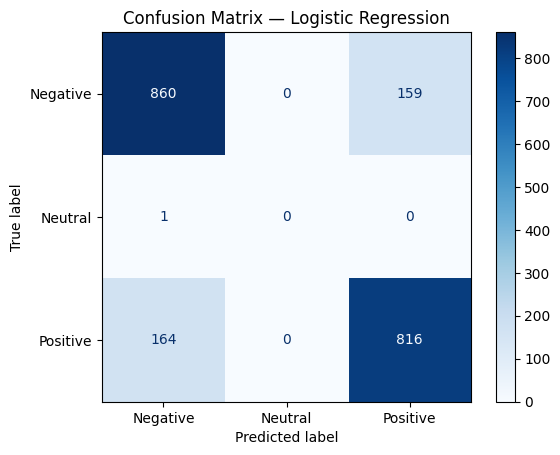

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

# Pick best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
best_preds = best_model.predict(X_test)

print(f"Best Model: {best_model_name} ({results[best_model_name]:.2%} accuracy)")

ConfusionMatrixDisplay.from_predictions(
    y_test, best_preds,
    display_labels=['Negative', 'Neutral', 'Positive'],
    cmap='Blues'
)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

In [20]:
import joblib

# Save model and vectorizer
joblib.dump(best_model, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print(f"✅ Model saved: sentiment_model.pkl")
print(f"✅ Vectorizer saved: tfidf_vectorizer.pkl")

✅ Model saved: sentiment_model.pkl
✅ Vectorizer saved: tfidf_vectorizer.pkl


In [21]:
!pip install pyngrok -q

In [22]:
app_code = '''
import streamlit as st
import joblib
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# Load model and vectorizer
model = joblib.load("sentiment_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\\s]", "", text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

# --- UI ---
st.set_page_config(page_title="Sentiment Analyzer", page_icon="💬")

st.title("💬 Customer Review Sentiment Analyzer")
st.markdown("Enter a customer review below and the AI will predict its sentiment.")

user_input = st.text_area("📝 Your Review", placeholder="Type your review here...", height=150)

if st.button("Analyze Sentiment"):
    if user_input.strip() == "":
        st.warning("Please enter a review first.")
    else:
        cleaned = clean_text(user_input)
        vectorized = vectorizer.transform([cleaned])
        prediction = model.predict(vectorized)[0]

        if prediction == "Positive":
            st.success("✅ Sentiment: **Positive** 😊")
        elif prediction == "Negative":
            st.error("❌ Sentiment: **Negative** 😞")
        else:
            st.info("➖ Sentiment: **Neutral** 😐")

st.markdown("---")
st.caption("Built with scikit-learn + Streamlit | TCS Industry Project")
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ app.py written successfully!")

✅ app.py written successfully!


In [27]:
from pyngrok import ngrok
import subprocess, time

# Start Streamlit in background
proc = subprocess.Popen(["streamlit", "run", "app.py",
                         "--server.port=8501",
                         "--server.headless=true"])
time.sleep(4)

# Create public tunnel
public_url = ngrok.connect(8501)
print("🚀 App is live at:", public_url)

🚀 App is live at: NgrokTunnel: "https://abstractively-semitheological-ruthe.ngrok-free.dev" -> "http://localhost:8501"


In [28]:
from pyngrok import ngrok
from google.colab import userdata
import subprocess, time

# Read token securely from Colab Secrets
ngrok.set_auth_token(userdata.get('Ngroq'))

# Start Streamlit in background
proc = subprocess.Popen(["streamlit", "run", "app.py",
                         "--server.port=8501",
                         "--server.headless=true"])
time.sleep(4)

# Create public tunnel
public_url = ngrok.connect(8501)
print("🚀 App is live at:", public_url)

🚀 App is live at: NgrokTunnel: "https://abstractively-semitheological-ruthe.ngrok-free.dev" -> "http://localhost:8501"
